<a href="https://colab.research.google.com/github/Yasinnn7/CODSOFT-ML/blob/main/Credit_Card__Transactions__Fraud_Detection_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

In [22]:
df_train=pd.read_csv(r'/content/fraudTrain.csv')
df_test=pd.read_csv(r'/content/fraudTest.csv' )

In [23]:
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [24]:
df_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


In [25]:
df_train.count()

,0
Unnamed: 0,7815
trans_date_trans_time,7815
cc_num,7815
merchant,7815
category,7815
amt,7815
first,7815
last,7815
gender,7814
street,7814


In [26]:
df_test.count()

,0
Unnamed: 0,7798
trans_date_trans_time,7798
cc_num,7798
merchant,7798
category,7798
amt,7798
first,7798
last,7798
gender,7798
street,7798


In [27]:
df_train.shape

(7815, 23)

In [28]:
df_test.shape

(7798, 23)

In [29]:
df_train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,7815.00000,7.815000e+03,7815.000000,7814.000000,7814.000000,7814.000000,7.814000e+03,7.814000e+03,7814.000000,7814.000000,7814.000000
mean,3907.00000,4.078117e+17,68.661363,49479.396340,38.595821,-90.688408,8.823451e+04,1.325583e+09,38.599153,-90.685832,0.005759
std,2256.14051,1.295068e+18,115.530027,27184.827244,5.198199,14.512405,2.944470e+05,1.359720e+05,5.226026,14.532152,0.075673
min,0.00000,6.041621e+10,1.010000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.165823,-166.550779,0.000000
25%,1953.50000,1.800184e+14,9.785000,26041.000000,34.852700,-97.235100,7.410000e+02,1.325448e+09,34.913072,-97.322865,0.000000
50%,3907.00000,3.518759e+15,48.490000,49259.000000,39.376400,-87.764400,2.395000e+03,1.325583e+09,39.392224,-87.772889,0.000000
75%,5860.50000,4.653879e+15,82.220000,72476.000000,41.846700,-80.143075,1.905400e+04,1.325704e+09,41.923981,-80.187209,0.000000
max,7814.00000,4.992346e+18,3178.510000,99783.000000,65.689900,-67.950300,2.906700e+06,1.325815e+09,66.645176,-66.967742,1.000000


In [30]:
df_test.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,7798.000000,7.798000e+03,7798.000000,7798.000000,7798.000000,7798.000000,7.798000e+03,7.797000e+03,7797.000000,7797.000000,7797.000000
mean,3898.500000,4.045046e+17,68.658160,48467.937548,38.486395,-89.976821,9.835233e+04,1.371903e+09,38.467741,-89.975801,0.002822
std,2251.233033,1.293290e+18,122.077687,26765.475620,5.088719,13.600215,3.330378e+05,4.968043e+04,5.124246,13.621047,0.053047
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.163455,-166.464422,0.000000
25%,1949.250000,1.800462e+14,9.450000,26237.000000,34.509100,-96.601200,7.722500e+02,1.371858e+09,34.627939,-96.577261,0.000000
50%,3898.500000,3.518235e+15,46.345000,47987.000000,39.342600,-86.947500,2.691000e+03,1.371908e+09,39.320289,-87.193562,0.000000
75%,5847.750000,4.642255e+15,81.600000,72011.000000,42.015800,-80.175200,2.219100e+04,1.371941e+09,42.011157,-80.269768,0.000000
max,7797.000000,4.992346e+18,3204.980000,99783.000000,65.689900,-67.950300,2.906700e+06,1.371993e+09,65.951727,-67.122946,1.000000


In [31]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7815 entries, 0 to 7814
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7815 non-null   int64  
 1   trans_date_trans_time  7815 non-null   object 
 2   cc_num                 7815 non-null   int64  
 3   merchant               7815 non-null   object 
 4   category               7815 non-null   object 
 5   amt                    7815 non-null   float64
 6   first                  7815 non-null   object 
 7   last                   7815 non-null   object 
 8   gender                 7814 non-null   object 
 9   street                 7814 non-null   object 
 10  city                   7814 non-null   object 
 11  state                  7814 non-null   object 
 12  zip                    7814 non-null   float64
 13  lat                    7814 non-null   float64
 14  long                   7814 non-null   float64
 15  city

In [32]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7798 entries, 0 to 7797
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7798 non-null   int64  
 1   trans_date_trans_time  7798 non-null   object 
 2   cc_num                 7798 non-null   int64  
 3   merchant               7798 non-null   object 
 4   category               7798 non-null   object 
 5   amt                    7798 non-null   float64
 6   first                  7798 non-null   object 
 7   last                   7798 non-null   object 
 8   gender                 7798 non-null   object 
 9   street                 7798 non-null   object 
 10  city                   7798 non-null   object 
 11  state                  7798 non-null   object 
 12  zip                    7798 non-null   int64  
 13  lat                    7798 non-null   float64
 14  long                   7798 non-null   float64
 15  city

In [33]:
df_train.dropna(inplace=True)

In [34]:
df_train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [35]:
df_test.dropna(inplace=True)

In [36]:
df_test.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [37]:
df_combined=pd.concat([df_train,df_test],axis=0)

In [38]:
df_combined.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [39]:
df_combined.shape

(15611, 23)

In [40]:
df_combined.size

359053

In [41]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15611 entries, 0 to 7796
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             15611 non-null  int64  
 1   trans_date_trans_time  15611 non-null  object 
 2   cc_num                 15611 non-null  int64  
 3   merchant               15611 non-null  object 
 4   category               15611 non-null  object 
 5   amt                    15611 non-null  float64
 6   first                  15611 non-null  object 
 7   last                   15611 non-null  object 
 8   gender                 15611 non-null  object 
 9   street                 15611 non-null  object 
 10  city                   15611 non-null  object 
 11  state                  15611 non-null  object 
 12  zip                    15611 non-null  float64
 13  lat                    15611 non-null  float64
 14  long                   15611 non-null  float64
 15  city_pop

In [42]:
df_combined.drop(labels=['Unnamed: 0','trans_date_trans_time','first','last','street','city','state','zip','dob','trans_num','unix_time'],axis=1,inplace=True)

In [43]:
df_combined.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495.0,"Psychologist, counselling",36.011293,-82.048315,0.0
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149.0,Special educational needs teacher,49.159047,-118.186462,0.0
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154.0,Nature conservation officer,43.150704,-112.154481,0.0
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939.0,Patent attorney,47.034331,-112.561071,0.0
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99.0,Dance movement psychotherapist,38.674999,-78.632459,0.0


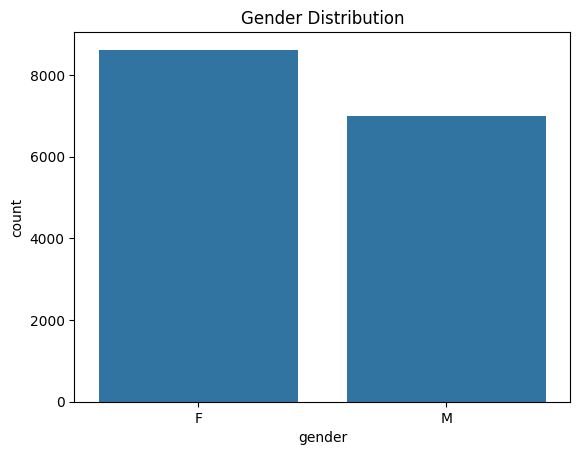

In [44]:
sns.countplot(x='gender', data=df_combined)
plt.title('Gender Distribution')
plt.show()

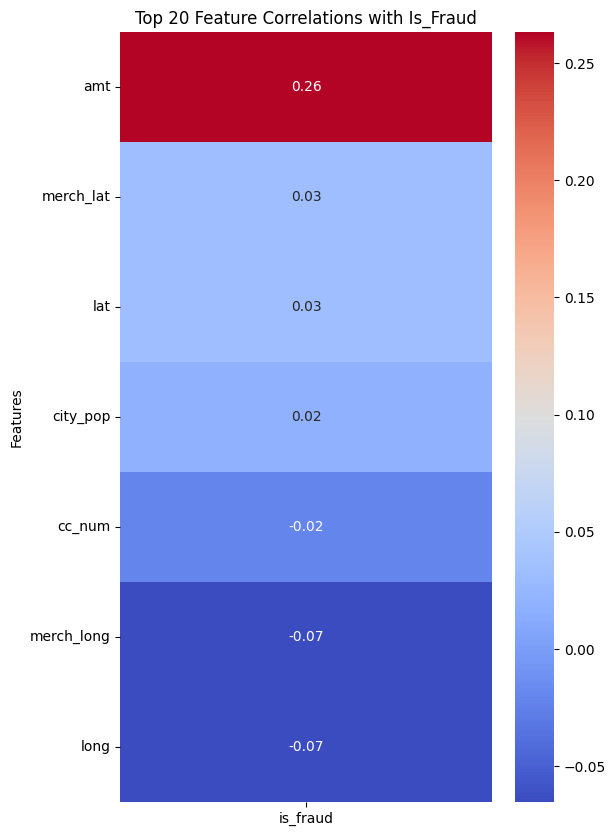

In [45]:
numeric_df = df_combined.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
correlation_with_fraud = correlation_matrix['is_fraud'].sort_values(ascending=False).drop('is_fraud')

n_top_features = 20
top_correlated_features = correlation_with_fraud.head(n_top_features)

plt.figure(figsize=(6, 10))
sns.heatmap(top_correlated_features.to_frame(), cmap='coolwarm', annot=True, fmt=".2f", cbar=True)
plt.title(f'Top {n_top_features} Feature Correlations with Is_Fraud')
plt.ylabel('Features')
plt.yticks(rotation=0)
plt.show()

In [46]:
lr=LabelEncoder()
new_col=lr.fit_transform(df_combined['merchant'].values)
df_combined['merchant']=new_col
df_combined.drop(labels=['merchant'], axis=1, inplace=True)

In [47]:
lr=LabelEncoder()
new_col1=lr.fit_transform(df_combined['category'].values)
df_combined['category']=new_col1
df_combined.drop(labels=['category'], axis=1, inplace=True)

In [48]:
df_combined=pd.get_dummies(df_combined)
df_combined.drop(labels=['gender_F'], axis=1,inplace=True)


In [49]:
df_combined.head()

,cc_num,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,gender_M,job_Academic librarian,...,job_Video editor,job_Visual merchandiser,job_Volunteer coordinator,job_Warden/ranger,job_Waste management officer,job_Water engineer,job_Water quality scientist,job_Web designer,job_Wellsite geologist,job_Writer
0,2703186189652095,4.97,36.0788,-81.1781,3495.0,36.011293,-82.048315,0.0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,630423337322,107.23,48.8878,-118.2105,149.0,49.159047,-118.186462,0.0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,38859492057661,220.11,42.1808,-112.2620,4154.0,43.150704,-112.154481,0.0,True,False,...,False,False,False,False,False,False,False,False,False,False
3,3534093764340240,45.00,46.2306,-112.1138,1939.0,47.034331,-112.561071,0.0,True,False,...,False,False,False,False,False,False,False,False,False,False
4,375534208663984,41.96,38.4207,-79.4629,99.0,38.674999,-78.632459,0.0,True,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
x=df_combined.drop('is_fraud', axis=1)
y=df_combined['is_fraud']

In [51]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Train logistic Regression Model

In [52]:
LOG_reg=LogisticRegression()
LOG_reg.fit(x_train,y_train)

LogisticRegression()

In [53]:
LR_prediction=LOG_reg.predict(x_test)

In [54]:
print("Logistic Regression Model: ")
print(confusion_matrix(y_test,LR_prediction))
print(classification_report(y_test,LR_prediction))
print("Accuracy", accuracy_score(y_test, LR_prediction))

Logistic Regression Model: 
[[3104    0]
 [  19    0]]
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3104
         1.0       0.00      0.00      0.00        19

    accuracy                           0.99      3123
   macro avg       0.50      0.50      0.50      3123
weighted avg       0.99      0.99      0.99      3123

Accuracy 0.9939161063080372


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Train Decision Tree Model

In [55]:
DT_model=DecisionTreeClassifier()
DT_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [56]:
DT_prediction=DT_model.predict(x_test)

In [57]:
print("Decision Tree Model: ")
print(confusion_matrix(y_test,DT_prediction))
print(classification_report(y_test,DT_prediction))
print("Accuracy", accuracy_score(y_test, DT_prediction))

Decision Tree Model: 
[[3100    4]
 [   9   10]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3104
         1.0       0.71      0.53      0.61        19

    accuracy                           1.00      3123
   macro avg       0.86      0.76      0.80      3123
weighted avg       1.00      1.00      1.00      3123

Accuracy 0.9958373358949728


# Train Random Forest Model

In [58]:
RF_model=RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=42)
RF_model.fit(x_train,y_train)

RandomForestClassifier(n_jobs=1, random_state=42)

In [59]:
RF_prediction=RF_model.predict(x_test)

In [60]:
print("Random Forest Model: ")
print(confusion_matrix(y_test,RF_prediction))
print(classification_report(y_test,RF_prediction))
print("Accuracy", accuracy_score(y_test, RF_prediction))

Random Forest Model: 
[[3103    1]
 [  10    9]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3104
         1.0       0.90      0.47      0.62        19

    accuracy                           1.00      3123
   macro avg       0.95      0.74      0.81      3123
weighted avg       1.00      1.00      1.00      3123

Accuracy 0.9964777457572846
